# Train GGPKD Top-K-only, no configured negatives (Colab)

Notebook ablation: use exactly `TOPK_QUOTA` candidate slots, all assigned to graph Top-K support (`hard_neg_k=0`, `random_neg_k=0`).

In [2]:
#@title 1. Cấu hình experiment
REPO_URL = "https://github.com/Savoxism/AAAI-TALAS.git"
BRANCH = "nqd_ablation"

PAIR_KEY = "qwen3_0_6b_to_minilmv2_h384" #@param
# ["qwen3_0_6b_to_minilmv2_h384", "bge_m3_to_minilmv2_h768", "qwen3_4b_to_bert_base"]

# Ablation Top-K-only: candidate width = TOPK_QUOTA + 0 hard + 0 random.
# TOPK_QUOTA được truyền explicit, không dùng quota tự suy ra từ graph.
TOPK_QUOTA = 500 #@param {type:"integer"}
HARD_NEG_K = 0
RANDOM_NEG_K = 0
SUPPORT_POLICY = "topk"
DIFFUSION_SCALES = "1"  # paper protocol R={1}

ROW_WEIGHT = 1.0 #@param {type:"number"}
ROW_START_EPOCH = 1 #@param {type:"integer"}

RUN_NAME = "topk_no_neg" #@param {type:"string"}

BATCH_SIZE = 64 #@param {type:"integer"}
EPOCHS = 5 #@param {type:"integer"}
# 3e-5 là arm thắng từ config; run 77.89 trước đó chạy 2e-5 và có chữ ký
# undertrain rõ (loss còn giảm ở epoch 4→5, student_top1 còn tăng).
LEARNING_RATE = 3e-5 #@param {type:"number"}
MAX_LENGTH = 256 #@param {type:"integer"}
SEED = 42 #@param {type:"integer"}
NUM_WORKERS = 4 #@param {type:"integer"}
TRAIN_DATA = "data/train_set/merged_3_data_5k_each.csv" #@param {type:"string"}

FINAL_WEIGHTS_ONLY = True #@param {type:"boolean"}
REQUIRE_GPU = True #@param {type:"boolean"}

USE_GOOGLE_DRIVE = False #@param {type:"boolean"}
DRIVE_ROOT = "/content/drive/MyDrive/embedding-kd-runs" #@param {type:"string"}

# Thêm CLI flags không liên quan allocation nếu cần. Các flag Top-K/negative/R
# được khóa trong cell train để tránh EXTRA_ARGS vô tình override ablation.
EXTRA_ARGS = "--direct_temp 0" #@param {type:"string"}

assert ROW_WEIGHT >= 0, "ROW_WEIGHT phải không âm"
assert ROW_START_EPOCH >= 1, "ROW_START_EPOCH phải bắt đầu từ 1"
assert TOPK_QUOTA > 0, "TOPK_QUOTA phải dương"
assert HARD_NEG_K == 0 and RANDOM_NEG_K == 0, "Notebook này khóa negatives bằng 0"
assert DIFFUSION_SCALES == "1", "No-negative arm phải giữ canonical R={1}"
assert BATCH_SIZE > 0 and EPOCHS > 0 and MAX_LENGTH > 0

# Mỗi quota/seed ghi vào thư mục riêng để không đè lên run khác.
RUN_TAG = (
    f"{RUN_NAME}_w{ROW_WEIGHT:g}_e{ROW_START_EPOCH}"
    f"_r1_topk{TOPK_QUOTA}_h0_n0_lr{LEARNING_RATE:g}_seed{SEED}"
)


In [ ]:
# 2. Clone lần đầu; các lần Run all sau luôn fetch/reset về đúng remote head
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/embedding-kd")


def git(*args, capture=False):
    command = ["git", "-C", str(REPO_DIR), *args]
    if capture:
        return subprocess.check_output(command, text=True).strip()
    print("+", " ".join(command))
    subprocess.run(command, check=True)


if (REPO_DIR / ".git").is_dir():
    before = git("rev-parse", "HEAD", capture=True)
    git("remote", "set-url", "origin", REPO_URL)
    # Fetch tường minh BRANCH thay vì dựa vào refspec của `clone --single-branch`:
    # clone cũ chỉ theo dõi đúng một nhánh, nên đổi BRANCH ở cell 1 rồi rerun sẽ
    # làm `checkout origin/<BRANCH mới>` fail vì ref đó chưa bao giờ được fetch.
    git("fetch", "--prune", "origin",
        f"+refs/heads/{BRANCH}:refs/remotes/origin/{BRANCH}")
    git("checkout", "-B", BRANCH, f"origin/{BRANCH}")
    # `reset --hard` bỏ sửa đổi tracked; `clean -fd` bỏ file untracked còn sót từ
    # commit cũ. `clean -fd` KHÔNG đụng file bị .gitignore, nên cache/, logs/,
    # models/ vẫn nguyên -- đừng bao giờ thêm -x vào đây, teacher cache và graph
    # artifact nằm trong số đó và sẽ phải tính lại từ đầu.
    git("reset", "--hard", f"origin/{BRANCH}")
    git("clean", "-fd")
    after = git("rev-parse", "HEAD", capture=True)
    moved = "đã cập nhật" if before != after else "đã là mới nhất"
    print(f"Clone sẵn có: {before[:12]} -> {after[:12]}  ({moved})")
elif REPO_DIR.exists() and any(REPO_DIR.iterdir()):
    raise RuntimeError(f"{REPO_DIR} tồn tại nhưng không phải Git repository")
else:
    # Không dùng --single-branch: giữ refspec đầy đủ để lần sau đổi BRANCH vẫn fetch được.
    subprocess.run(
        ["git", "clone", "--branch", BRANCH, REPO_URL, str(REPO_DIR)],
        check=True,
    )

# Khẳng định code đang chạy đúng bằng remote head, thay vì chỉ in ra rồi tin.
head = git("rev-parse", "HEAD", capture=True)
remote_head = git("rev-parse", f"origin/{BRANCH}", capture=True)
if head != remote_head:
    raise RuntimeError(
        f"HEAD ({head[:12]}) khác origin/{BRANCH} ({remote_head[:12]}) -- "
        "code đang chạy không phải bản trên GitHub"
    )
print(f"Ready: {BRANCH}@{head[:12]} — {git('log', '-1', '--pretty=%s', capture=True)}")


In [4]:
# 3. Cài/đồng bộ dependencies theo code vừa pull
import os
import sys

os.chdir(REPO_DIR)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_DIR / "requirements.txt")],
    check=True,
)
print("Dependencies are ready.")


Dependencies are ready.


In [5]:
# 4. Resolve model pair, GPU và nơi lưu artifacts
import torch

PAIR_CONFIGS = {
    "qwen3_0_6b_to_minilmv2_h384": {
        "teacher": "Qwen/Qwen3-Embedding-0.6B",
        "student": "nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base",
        "pooling": "last_token",
    },
    "bge_m3_to_minilmv2_h768": {
        "teacher": "BAAI/bge-m3",
        "student": "nreimers/MiniLMv2-L6-H768-distilled-from-BERT-Base",
        "pooling": "cls",
    },
    "qwen3_4b_to_bert_base": {
        "teacher": "Qwen/Qwen3-Embedding-4B",
        "student": "google-bert/bert-base-uncased",
        "pooling": "last_token",
    },
}
pair = PAIR_CONFIGS[PAIR_KEY]

if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("Không tìm thấy CUDA GPU. Trong Colab chọn Runtime → Change runtime type → GPU.")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 2**30
    print(f"GPU: {props.name} ({vram_gb:.1f} GiB)")
    if PAIR_KEY == "qwen3_4b_to_bert_base" and vram_gb < 35:
        print("WARNING: Qwen3-4B ở cấu hình hiện tại có thể OOM trên GPU dưới khoảng 35 GiB.")

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    artifact_root = Path(DRIVE_ROOT)
else:
    artifact_root = REPO_DIR

# Teacher cache dùng chung; graph cache mang r1 để không tái dùng nhầm artifact
# multi-hop từ notebook gốc.
cache_dir = artifact_root / "cache" / "ggpkd" / PAIR_KEY
log_dir = artifact_root / "logs" / "ggpkd" / PAIR_KEY
save_dir = artifact_root / "models" / "ggpkd" / PAIR_KEY / RUN_TAG
weights_dir = artifact_root / "models" / "ggpkd_weights" / PAIR_KEY / RUN_TAG
for path in (cache_dir, log_dir, save_dir, weights_dir):
    path.mkdir(parents=True, exist_ok=True)

print(f"Teacher: {pair['teacher']}")
print(f"Student: {pair['student']}")
print(f"Pooling: {pair['pooling']}")
print(f"Objective: L_rel + {ROW_WEIGHT} * L_row")
print(f"Row starts at epoch: {ROW_START_EPOCH}")
print(f"Diffusion scales: {DIFFUSION_SCALES}")
print(f"Candidate allocation: topk={TOPK_QUOTA}, hard=0, random=0")
print(f"Candidate width: {TOPK_QUOTA}")
print(f"Outputs: {save_dir}")


GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GiB)
Teacher: Qwen/Qwen3-Embedding-0.6B
Student: nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
Pooling: last_token
Objective: L_rel + 1.0 * L_row
Row starts at epoch: 1
Diffusion scales: 1
Candidate allocation: topk=500, hard=0, random=0
Candidate width: 500
Outputs: /content/embedding-kd/models/ggpkd/qwen3_0_6b_to_minilmv2_h384/topk_no_neg_w1_e1_r1_topk500_h0_n0_lr3e-05_seed42


In [6]:
# 5. Train GGPKD
import shlex

extra_args = shlex.split(EXTRA_ARGS)
locked_flags = {"--support_policy", "--diffusion_quota", "--diffusion_scales",
                "--hard_neg_k", "--random_neg_k"}
overrides = sorted(locked_flags.intersection(extra_args))
if overrides:
    raise ValueError(f"EXTRA_ARGS không được override các flag đã khóa: {overrides}")

command = [
    sys.executable, "main.py",
    "--method", "ggpkd",
    "--train_data", TRAIN_DATA,
    "--student_model", pair["student"],
    "--teacher_model", pair["teacher"],
    "--pooling_method", pair["pooling"],
    "--support_policy", SUPPORT_POLICY,
    "--diffusion_quota", str(TOPK_QUOTA),
    "--diffusion_scales", DIFFUSION_SCALES,
    "--hard_neg_k", str(HARD_NEG_K),
    "--random_neg_k", str(RANDOM_NEG_K),
    "--row_weight", str(ROW_WEIGHT),
    "--row_start_epoch", str(ROW_START_EPOCH),
    "--batch_size", str(BATCH_SIZE),
    "--epochs", str(EPOCHS),
    "--eval_every", "0",
    "--lr", str(LEARNING_RATE),
    "--max_length", str(MAX_LENGTH),
    "--seed", str(SEED),
    "--num_workers", str(NUM_WORKERS),
    "--cache_path", str(cache_dir / "teacher_train.pt"),
    "--ggpkd_cache_path", str(cache_dir / "graph_r1.pt"),
    "--ggpkd_log_dir", str(log_dir),
    "--save_dir", str(save_dir),
    "--weights_dir", str(weights_dir),
]
if FINAL_WEIGHTS_ONLY:
    command.append("--final_weights_only")
if extra_args:
    command.extend(extra_args)

env = os.environ.copy()
env["TOKENIZERS_PARALLELISM"] = "false"
env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print("+", shlex.join(command))
process = subprocess.Popen(
    command,
    cwd=REPO_DIR,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
for line in process.stdout:
    print(line, end="")
return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f"Training failed with exit code {return_code}")


+ /usr/bin/python3 main.py --method ggpkd --train_data data/train_set/merged_3_data_5k_each.csv --student_model nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base --teacher_model Qwen/Qwen3-Embedding-0.6B --pooling_method last_token --support_policy topk --diffusion_quota 500 --diffusion_scales 1 --hard_neg_k 0 --random_neg_k 0 --row_weight 1.0 --row_start_epoch 1 --batch_size 64 --epochs 5 --eval_every 0 --lr 3e-05 --max_length 256 --seed 42 --num_workers 4 --cache_path /content/embedding-kd/cache/ggpkd/qwen3_0_6b_to_minilmv2_h384/teacher_train.pt --ggpkd_cache_path /content/embedding-kd/cache/ggpkd/qwen3_0_6b_to_minilmv2_h384/graph_r1.pt --ggpkd_log_dir /content/embedding-kd/logs/ggpkd/qwen3_0_6b_to_minilmv2_h384 --save_dir /content/embedding-kd/models/ggpkd/qwen3_0_6b_to_minilmv2_h384/topk_no_neg_w1_e1_r1_topk500_h0_n0_lr3e-05_seed42 --weights_dir /content/embedding-kd/models/ggpkd_weights/qwen3_0_6b_to_minilmv2_h384/topk_no_neg_w1_e1_r1_topk500_h0_n0_lr3e-05_seed42 --final_weights_

In [7]:
# 6. Xem artifacts và các metrics cuối
import json

print("Checkpoints:", save_dir)
print("Weights:", weights_dir)
metrics_path = save_dir / "metrics.jsonl"
if metrics_path.exists():
    records = [json.loads(line) for line in metrics_path.read_text().splitlines() if line.strip()]
    print(json.dumps(records[-1], indent=2, ensure_ascii=False) if records else "metrics.jsonl is empty")
else:
    print("Không tìm thấy metrics.jsonl")

Checkpoints: /content/embedding-kd/models/ggpkd/qwen3_0_6b_to_minilmv2_h384/topk_no_neg_w1_e1_r1_topk500_h0_n0_lr3e-05_seed42
Weights: /content/embedding-kd/models/ggpkd_weights/qwen3_0_6b_to_minilmv2_h384/topk_no_neg_w1_e1_r1_topk500_h0_n0_lr3e-05_seed42
{
  "method": "ggpkd",
  "run_id": "20260908-170014-83d657",
  "seed": 42,
  "test": null,
  "train": {
    "amb_diff_js_own": 0.07947802049288817,
    "amb_mass_on_zero_diff": 0.0,
    "amb_mass_own": 0.50735824353887,
    "candidates_per_anchor": 66.82708827014218,
    "encoded_texts_cum": 3783037,
    "encoded_tokens_cum": 51921002,
    "epoch": 5,
    "excess_is_exact": 0.0,
    "grad_norm": 1.9779899786998876,
    "js_floor": 1.067710572509404e-08,
    "kl_amb": 0.47923458201625335,
    "kl_nbr": 0.3579973072802286,
    "loss": 0.8327503950109979,
    "loss_amb": 0.47923458116879397,
    "loss_cross_entropy": 4.726402409268782,
    "loss_diff": 0.0,
    "loss_excess": 0.4186159337018903,
    "loss_nbr": 0.3579973101050933,
    "l

In [8]:
# 7. Phân tích run: run.json / metrics.jsonl / epochs.jsonl / step_metrics.jsonl
# Các file đều append-mode, nên mọi thứ được lọc theo run_id của run mới nhất
# (run.json bị ghi đè mỗi lần train nên luôn trỏ vào run vừa chạy).
import json
from pathlib import Path

import pandas as pd

RUN_DIR = Path(save_dir)  # save_dir đến từ cell 4; sửa tay nếu chạy cell này rời


def read_jsonl(path, run_id=None):
    path = Path(path)
    if not path.exists():
        return []
    rows = [json.loads(l) for l in path.read_text().splitlines() if l.strip()]
    if run_id is not None:
        rows = [r for r in rows if r.get("run_id") == run_id]
    return rows


manifest = json.loads((RUN_DIR / "run.json").read_text())
run_id = manifest["run_id"]
cfg = manifest.get("config", {})
git = manifest.get("git", {})
graph = manifest.get("artifact", {}).get("graph_stats", {})

print(f"run_id      : {run_id}")
print(f"git         : {git.get('branch')}@{str(git.get('sha'))[:12]}"
      f"{' (DIRTY — sha không tái lập được run này)' if git.get('dirty') else ''}")
print("config      : " + ", ".join(
    f"{k}={cfg.get(k)}" for k in
    ("support_policy", "diffusion_scales", "diffusion_quota",
     "hard_neg_k", "random_neg_k",
     "row_weight", "row_start_epoch", "row_mode", "learning_rate",
     "epochs", "batch_size", "seed") if k in cfg))
expected_allocation = {
    "support_policy": SUPPORT_POLICY,
    "diffusion_quota": TOPK_QUOTA,
    "hard_neg_k": 0,
    "random_neg_k": 0,
}
mismatch = {k: (cfg.get(k), expected) for k, expected in expected_allocation.items()
            if cfg.get(k) != expected}
if mismatch:
    raise RuntimeError(f"Run không dùng đúng Top-K-only allocation: {mismatch}")
if tuple(cfg.get("diffusion_scales", ())) != (1,):
    raise RuntimeError(f"Run không dùng canonical R={{1}}: {cfg.get('diffusion_scales')}")
if graph:
    print("graph_stats : " + ", ".join(f"{k}={v}" for k, v in sorted(graph.items())))

# ---- Bảng per-epoch: train means + geometry probe -------------------------
epochs = read_jsonl(RUN_DIR / "epochs.jsonl", run_id)
if epochs:
    rows = []
    for r in epochs:
        flat = {"epoch": r.get("epoch")}
        flat.update({k: v for k, v in (r.get("train") or {}).items()
                     if isinstance(v, (int, float))})
        flat.update({f"geo_{k}": v for k, v in (r.get("geometry") or {}).items()})
        if isinstance(r.get("test"), dict):
            flat["test_avg"] = r["test"].get("avg")
        rows.append(flat)
    df_epochs = pd.DataFrame(rows).set_index("epoch")

    train_cols = [c for c in (
        "loss", "loss_rel", "loss_row_weighted", "row_count", "row_exposed_mass",
        "row_valid_ratio", "target_entropy", "student_entropy",
        "student_entropy_ratio", "student_top1", "target_top1", "js_floor",
        "grad_norm", "mean_step_seconds") if c in df_epochs.columns]
    geo_cols = [c for c in (
        "geo_anisotropy", "geo_cos_std", "geo_effective_rank", "geo_uniformity",
        "geo_alignment", "geo_positive_cos_mean", "geo_separation",
        "geo_teacher_student_spearman", "geo_teacher_anisotropy") if c in df_epochs.columns]

    print("\n=== Train means theo epoch ===")
    display(df_epochs[train_cols].round(4))
    if geo_cols:
        print("=== Geometry probe theo epoch ===")
        display(df_epochs[geo_cols].round(4))
else:
    df_epochs = pd.DataFrame()
    print("\nKhông có dòng nào trong epochs.jsonl cho run này.")

# ---- Kết quả test cuối (eval_every=0 nên chỉ có một bản ở cuối run) --------
final = next((r for r in reversed(read_jsonl(RUN_DIR / "metrics.jsonl", run_id))
              if r.get("test")), None)
if final:
    t = final["test"]
    print(f"=== Test cuối ===  avg={t['avg']}  avg_in={t['avg_in']}  avg_out={t['avg_out']}")
    per_task = {}
    for domain in ("classification", "pair", "sts"):
        for path, res in (t.get(domain) or {}).items():
            name = Path(path).stem.replace("_test", "")
            if domain == "sts":
                per_task[name] = {"domain": "sts", "score": round(100 * res, 2)}
            else:
                key = "f1" if domain == "classification" else "average_precision"
                per_task[name] = {"domain": domain, "score": round(100 * res[key], 2),
                                  "f1": round(100 * res["f1"], 2)}
    display(pd.DataFrame(per_task).T)
else:
    print("Chưa có record test nào trong metrics.jsonl cho run này.")


run_id      : 20260908-170014-83d657
git         : nqd_ablation@abe586665223
config      : support_policy=topk, diffusion_scales=[1], diffusion_quota=500, hard_neg_k=0, random_neg_k=0, row_weight=1.0, row_start_epoch=1, learning_rate=3e-05, epochs=5, batch_size=64, seed=42
graph_stats : avg_degree=80.92082977294922, diffusion_capped_rows=0.0, diffusion_truncation_cum_r1=0.006560302646988481, diffusion_truncation_step1=0.006560302646988469, fallback_count=11, fallback_rate=0.0008116284217516418, graph_k=200, hard_pool_fill_avg=200.0, hard_pool_fill_min=200.0, hub_edge_share_top1pct=0.024850463199358085, indegree_gini=0.3673232358050724, indegree_max=204.0, indegree_mean=80.92082933667822, indegree_p50=71.0, indegree_p99=199.0, isolated_indegree_rate=0.0007378440197742198, max_degree=200.0, min_degree=1.0, n_items=13553, perplexity_clamped_rate=0.18888806906220026, perplexity_clamped_rows=2560, pool_capped_rows=0.0, pool_empty_r1=0.0, pool_fill_avg=66.82372906367594, pool_fill_min=1.0, p

,loss,loss_rel,loss_row_weighted,row_count,row_exposed_mass,row_valid_ratio,target_entropy,student_entropy,student_entropy_ratio,student_top1,target_top1,js_floor,grad_norm,mean_step_seconds
epoch,,,,,,,,,,,,,,
1,1.6522,0.8660,0.7862,3464.1327,0.5811,0.9987,4.3103,3.6372,0.9205,0.0854,0.1942,0.0,2.6368,0.5146
2,1.0885,0.5449,0.5436,3454.8815,0.5804,0.9987,4.3076,3.4717,0.8832,0.1171,0.1942,0.0,2.2745,0.4831
3,0.9325,0.4681,0.4644,3453.6540,0.5813,0.9987,4.3092,3.4272,0.8733,0.1272,0.1942,0.0,2.1880,0.4775
4,0.8625,0.4336,0.4289,3447.6161,0.5806,0.9986,4.3081,3.4082,0.8692,0.1317,0.1942,0.0,2.0451,0.4775
5,0.8328,0.4186,0.4141,3446.2701,0.5812,0.9987,4.3078,3.4030,0.8679,0.1331,0.1941,0.0,1.9780,0.4752


=== Geometry probe theo epoch ===


,geo_anisotropy,geo_cos_std,geo_effective_rank,geo_uniformity,geo_teacher_student_spearman,geo_teacher_anisotropy
epoch,,,,,,
1,0.5160,0.1406,226.4086,-1.7757,0.7870,0.3184
2,0.4788,0.1400,230.3228,-1.9262,0.8064,0.3184
3,0.4554,0.1380,232.0582,-2.0238,0.8184,0.3184
4,0.4594,0.1352,233.0492,-2.0140,0.8240,0.3184
5,0.4591,0.1358,233.4702,-2.0133,0.8249,0.3184


Chưa có record test nào trong metrics.jsonl cho run này.


/tmp/ipykernel_2712/2338547375.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  epoch_starts = df.groupby("epoch").apply(lambda g: g.index.min())


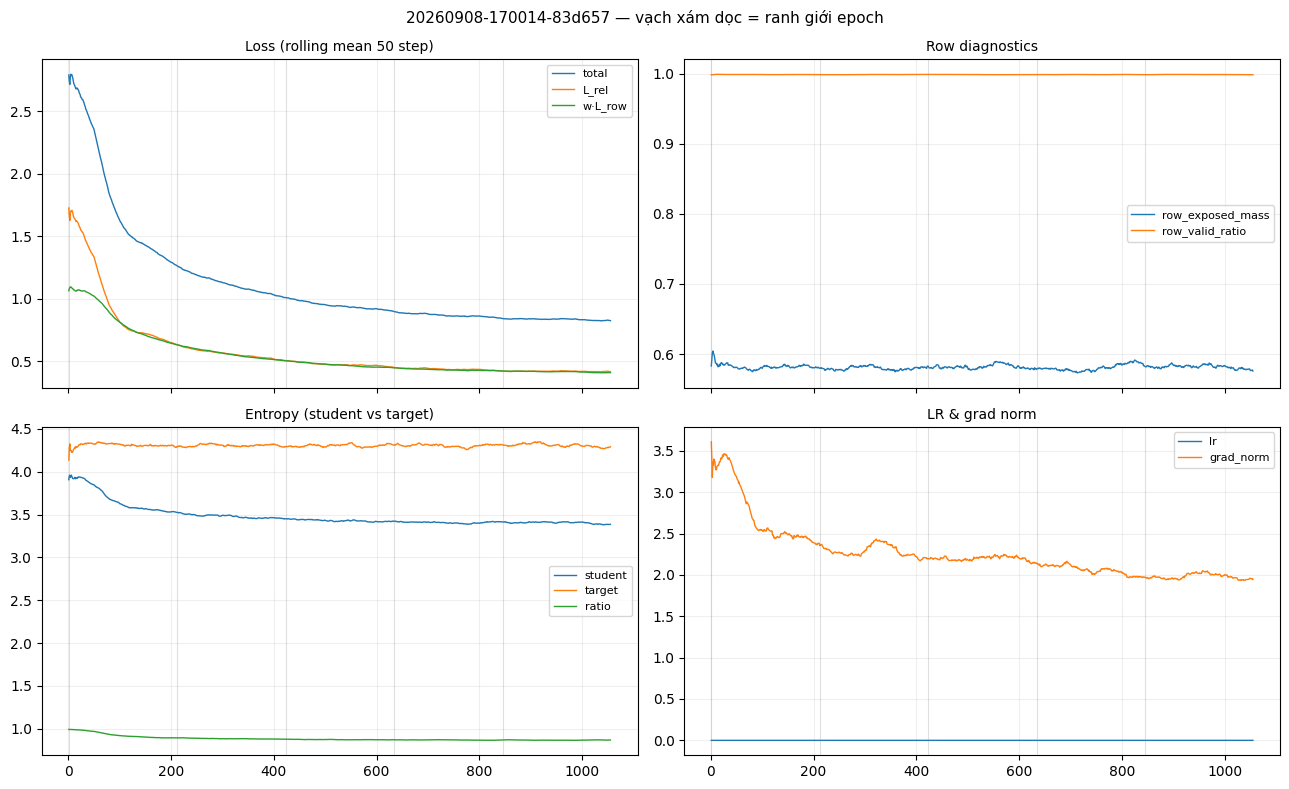

,first,last,mean,drop_in_epoch
epoch,,,,
1,2.7899,1.1509,1.6522,1.6390
2,1.1947,0.9961,1.0885,0.1986
3,0.9995,0.8567,0.9325,0.1428
4,0.8375,0.7728,0.8625,0.0647
5,0.8105,0.7798,0.8328,0.0307


In [9]:
# 8. Đồ thị step-level từ step_metrics.jsonl
import matplotlib.pyplot as plt

steps = read_jsonl(RUN_DIR / "step_metrics.jsonl", run_id)
if not steps:
    raise SystemExit("Không có step_metrics.jsonl cho run này.")

df = pd.DataFrame(steps).sort_values("global_step").set_index("global_step")
smooth = lambda s, w=50: s.rolling(w, min_periods=1).mean()

panels = [
    ("Loss (rolling mean 50 step)",
     [("loss", "total"), ("loss_rel", "L_rel"), ("loss_row_weighted", "w·L_row")]),
    ("Row diagnostics",
     [("row_exposed_mass", "row_exposed_mass"), ("row_valid_ratio", "row_valid_ratio")]),
    ("Entropy (student vs target)",
     [("student_entropy", "student"), ("target_entropy", "target"),
      ("student_entropy_ratio", "ratio")]),
    ("LR & grad norm",
     [("lr_next", "lr"), ("grad_norm", "grad_norm")]),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
epoch_starts = df.groupby("epoch").apply(lambda g: g.index.min())
for ax, (title, series) in zip(axes.flat, panels):
    drawn = False
    for col, label in series:
        if col in df.columns and df[col].notna().any():
            ax.plot(smooth(df[col]), label=label, linewidth=1)
            drawn = True
    for e, s in epoch_starts.items():
        ax.axvline(s, color="gray", alpha=0.25, linewidth=0.8)
    ax.set_title(title, fontsize=10)
    if drawn:
        ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
fig.suptitle(f"{run_id} — vạch xám dọc = ranh giới epoch", fontsize=11)
fig.tight_layout()
plt.show()

# Nhìn nhanh: loss step đầu/cuối mỗi epoch, để thấy còn giảm hay đã phẳng
ep_summary = df.groupby("epoch")["loss"].agg(["first", "last", "mean"]).round(4)
ep_summary["drop_in_epoch"] = (ep_summary["first"] - ep_summary["last"]).round(4)
display(ep_summary)


In [10]:
# 9. Kiểm tra support availability và exposure của Top-K-only từ graph.pt
# Mixture row của mỗi anchor nằm sẵn trong artifact; cumsum theo mass giảm dần
# cho thẳng đường cong "quota k thì exposure bao nhiêu" và trần khi quota→∞.
import numpy as np
import torch

art = torch.load(str(cache_dir / "graph_r1.pt"), map_location="cpu")
pool_probs = art["pool_probs"].numpy()                 # (n_scales, n_items, width)
scales = art["metadata"]["diffusion_scales"]
w = np.array([1.0 / r for r in scales]); w /= w.sum()  # omega_r = 1/r, như sampler
mix = (pool_probs * w.reshape(-1, 1, 1)).sum(0)
cum = np.cumsum(-np.sort(-mix, axis=1), axis=1)
positive_support = (mix > 0).sum(axis=1)
short_rows = positive_support < TOPK_QUOTA
print(f"Top-K-only yêu cầu K={TOPK_QUOTA}; anchor thiếu K support dương: "
      f"{short_rows.sum()}/{short_rows.size} ({short_rows.mean():.2%}).")
if short_rows.any():
    print("WARNING: sampler hiện tại sẽ backfill các slot thiếu bằng uniform nodes; "
          "hard_neg_k=random_neg_k=0 không đảm bảo tuyệt đối mọi candidate đều có diffusion mass.")


ceiling = cum[:, -1]
print(f"Trần exposure (quota→∞, do graph_k + truncation quyết định): "
      f"mean={ceiling.mean():.3f}  p10={np.quantile(ceiling, 0.1):.3f}")
print(f"{'quota':>6} {'mean':>7} {'p10':>7} {'p50':>7} {'p90':>7}")
probe_quotas = sorted(set((TOPK_QUOTA, 8, 11, 15, 23, 30, 38, 45, 64, 90, 128)))
for q in probe_quotas:
    m = cum[:, min(q, cum.shape[1]) - 1]
    print(f"{q:6d} {m.mean():7.3f} {np.quantile(m, 0.1):7.3f} "
          f"{np.quantile(m, 0.5):7.3f} {np.quantile(m, 0.9):7.3f}")

# Quota nhỏ nhất đạt coverage tau cho từng anchor — đọc ngược bảng trên.
for tau in (0.5, 0.6, 0.7, 0.8):
    reached = ceiling >= tau
    need = (cum >= tau).argmax(axis=1) + 1
    need = need[reached]
    print(f"tau={tau}: quota cần p50={np.median(need):.0f}  "
          f"p90={np.quantile(need, 0.9):.0f}  "
          f"({(~reached).mean():.1%} anchor không bao giờ đạt trần này)")


Top-K-only yêu cầu K=500; anchor thiếu K support dương: 13553/13553 (100.00%).
Trần exposure (quota→∞, do graph_k + truncation quyết định): mean=1.000  p10=1.000
 quota    mean     p10     p50     p90
     8   0.560   0.399   0.566   0.653
    11   0.637   0.501   0.637   0.722
    15   0.716   0.597   0.708   0.809
    23   0.822   0.720   0.812   1.000
    30   0.879   0.773   0.876   1.000
    38   0.919   0.818   0.924   1.000
    45   0.940   0.849   0.953   1.000
    64   0.973   0.910   1.000   1.000
    90   0.991   0.963   1.000   1.000
   128   0.999   1.000   1.000   1.000
   500   1.000   1.000   1.000   1.000
tau=0.5: quota cần p50=6  p90=11  (0.0% anchor không bao giờ đạt trần này)
tau=0.6: quota cần p50=10  p90=16  (0.0% anchor không bao giờ đạt trần này)
tau=0.7: quota cần p50=15  p90=22  (0.0% anchor không bao giờ đạt trần này)
tau=0.8: quota cần p50=22  p90=35  (0.0% anchor không bao giờ đạt trần này)
